# Importar bibliotecas e carregar os dados

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/world_happiness_report_colunas_pt_preprocessed.csv")

In [3]:
df_2 = df.copy()
df_2

,País,Ano,Índice de Felicidade,PIB per capita (US$),Apoio Social,Expectativa de vida,Liberdade de escolhas,Generosidade,Percepções de corrupção,Afeto Positivo,Afeto Negativo,Confiança no governo nacional
0,Afghanistan,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.167652,0.881686,0.414297,0.258195,0.612072
1,Afghanistan,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.190809,0.850035,0.481421,0.237092,0.611545
2,Afghanistan,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.121316,0.706766,0.516907,0.275324,0.299357
3,Afghanistan,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.163571,0.731109,0.479835,0.267175,0.307386
4,Afghanistan,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.237588,0.775620,0.613513,0.267919,0.435440
...,...,...,...,...,...,...,...,...,...,...,...,...
2194,Zimbabwe,2018,3.616480,7.783066,0.775388,52.625000,0.762675,-0.051219,0.844209,0.657524,0.211726,0.550508
2195,Zimbabwe,2019,2.693523,7.697755,0.759162,53.099998,0.631908,-0.047464,0.830652,0.658434,0.235354,0.456455
2196,Zimbabwe,2020,3.159802,7.596050,0.717243,53.575001,0.643303,0.006313,0.788523,0.660658,0.345736,0.577302
2197,Zimbabwe,2021,3.154578,7.656878,0.685151,54.049999,0.667636,-0.075575,0.756945,0.609917,0.241682,0.665703


# Treinando o modelo

## Definindo o target

In [4]:
target = "Índice de Felicidade"

y = df_2[target]
X = df_2.drop(columns=[target, "País"])  # remove também o nome do país, não é numérico
X = X.select_dtypes(include=[np.number])  # garante só números


## Dividir em treino e teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
   X,
   y,
   test_size=0.2,
   random_state=42
)

## Testando modelos

### Modelo linear

#### Treinando regressão linear

In [6]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Avaliando Modelo

In [7]:
y_pred = modelo_lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² no teste: {r2:.3f}, logo modelo explica {r2*100:.3f}% das diferenças de felicidade entre os países")
print(f"RMSE no teste: {rmse:.3f}, ou seja, com oo índice de felicidade vai de 0 a 10, o modelo erra {rmse:.3f} ponto(s)")

R² no teste: 0.755, logo modelo explica 75.535% das diferenças de felicidade entre os países
RMSE no teste: 0.535, ou seja, com oo índice de felicidade vai de 0 a 10, o modelo erra 0.535 ponto(s)


#### Visualizar Previsões x Valores Reais

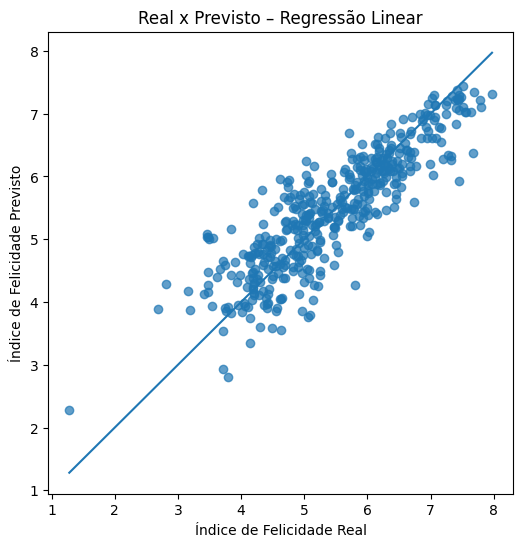

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Índice de Felicidade Real")
plt.ylabel("Índice de Felicidade Previsto")
plt.title("Real x Previsto – Regressão Linear")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

**Interpretação do gráfico:**
Os pontos seguem a diagonal, mas com dispersão em países abaixo e acima, o que indica que existe relação linear, mas também variabilidade que a linha não captura. Em outras palavras… dá para melhorar. Vale a pena tentar um modelo não-linear (exemplos: Random Forest Regressor e XGBoost Regressor)

### Modelos não lineares

#### Random Forest Regressor

A ideia do Random Forest é simples: em vez de uma linha tentando explicar tudo, ele cria várias árvores de decisão, cada uma aprendendo padrões diferentes, e depois junta tudo em um voto/regressão média. Isso costuma captar relações não lineares e melhorar bastante o resultado.

##### Importando e treinando

In [9]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
   n_estimators=300,   # quantidade de árvores
   max_depth=None,     # deixa a floresta crescer livre
   random_state=42
)

modelo_rf.fit(X_train, y_train)


,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##### Avaliar o modelo

In [10]:
y_pred_rf = modelo_rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"R² no teste: {r2_rf:.3f}, logo modelo explica {r2_rf*100:.3f}% das diferenças de felicidade entre os países")
print(f"RMSE no teste: {rmse_rf:.3f}, ou seja, com oo índice de felicidade vai de 0 a 10, o modelo erra {rmse_rf:.3f} ponto(s)")


R² no teste: 0.856, logo modelo explica 85.614% das diferenças de felicidade entre os países
RMSE no teste: 0.410, ou seja, com oo índice de felicidade vai de 0 a 10, o modelo erra 0.410 ponto(s)


##### Visualizar Previsões x Valores Reais

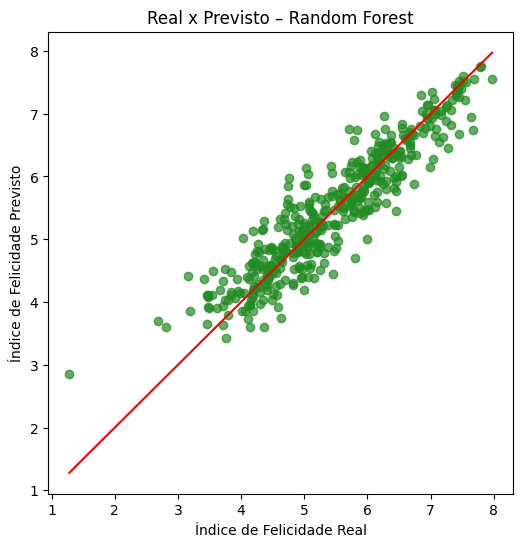

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color="forestgreen")
plt.xlabel("Índice de Felicidade Real")
plt.ylabel("Índice de Felicidade Previsto")
plt.title("Real x Previsto – Random Forest")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.show()

##### Importância das variáveis no Random Forest Regressor

c:\Users\felip\OneDrive\git_work\world-happiness-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


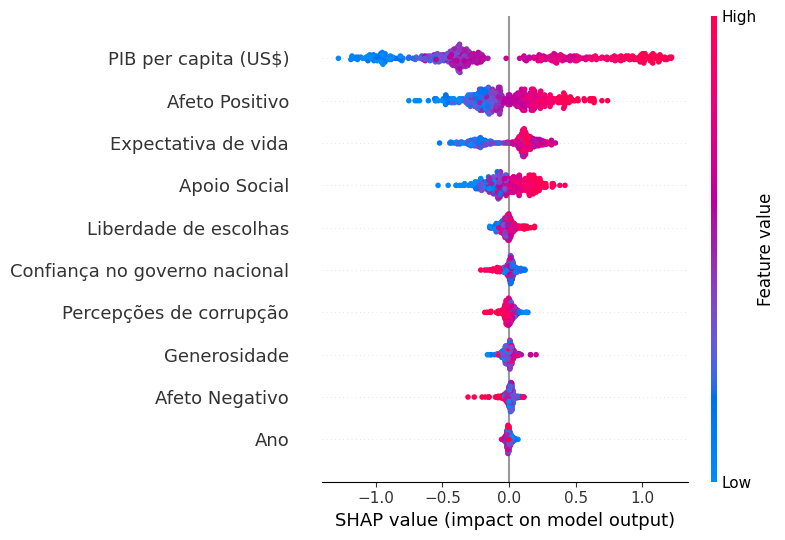

In [12]:
# importances_rf = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# importances_rf = pd.Series(
#    modelo_rf.feature_importances_, 
#    index=X.columns
# ).sort_values(ascending=False)

# plt.figure(figsize=(8,5))
# importances_rf.plot(kind='bar', color="darkorange")
# plt.title("Importância das Variáveis – Random Forest")
# plt.ylabel("Importância")
# plt.show()

# importances_rf

import shap

explainer = shap.TreeExplainer(modelo_rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)




#### XGBoost Regressor

##### Importando e treinando

In [13]:
from xgboost import XGBRegressor

modelo_xgb = XGBRegressor(
   n_estimators=500,
   learning_rate=0.05,
   max_depth=5,
   subsample=0.9,
   colsample_bytree=0.9,
   random_state=42,
   eval_metric="rmse"
)

modelo_xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


##### Avaliar o modelo

In [14]:
y_pred_xgb = modelo_xgb.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"R² no teste: {r2_xgb:.3f}, logo modelo explica {r2_xgb*100:.3f}% das diferenças de felicidade entre os países")
print(f"RMSE no teste: {rmse_xgb:.3f}, ou seja, com oo índice de felicidade vai de 0 a 10, o modelo erra {rmse_xgb:.3f} ponto(s)")

R² no teste: 0.850, logo modelo explica 85.019% das diferenças de felicidade entre os países
RMSE no teste: 0.418, ou seja, com oo índice de felicidade vai de 0 a 10, o modelo erra 0.418 ponto(s)


##### Visualizar Previsões x Valores Reais

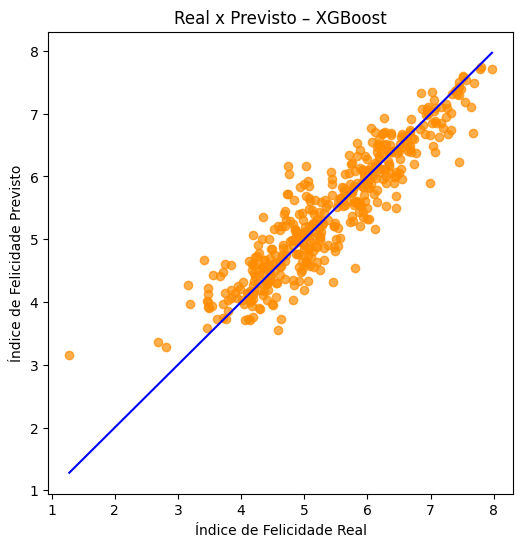

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.7, color="darkorange")
plt.xlabel("Índice de Felicidade Real")
plt.ylabel("Índice de Felicidade Previsto")
plt.title("Real x Previsto – XGBoost")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="blue")
plt.show()


##### Importância das variáveis no XGBoost

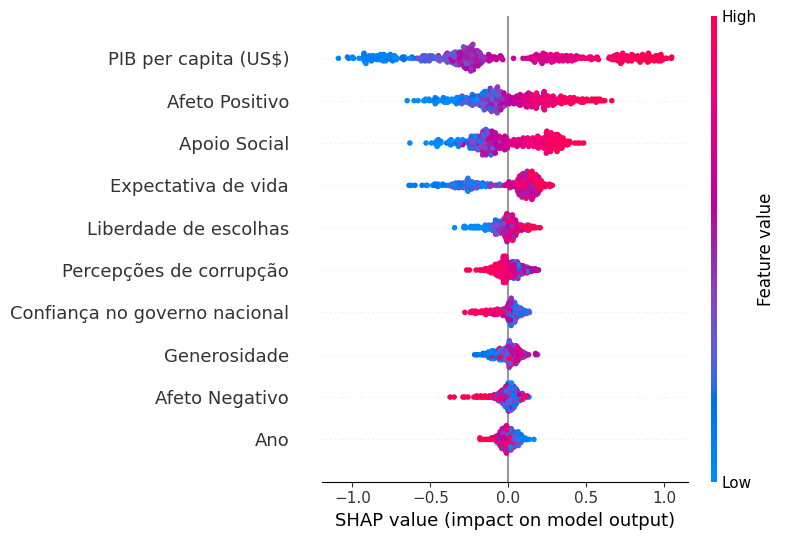

In [16]:
# importances_xgb = pd.Series(
#    modelo_xgb.feature_importances_, 
#    index=X.columns
# ).sort_values(ascending=False)

# plt.figure(figsize=(8,5))
# importances_xgb.plot(kind='bar', color="darkorange")
# plt.title("Importância das Variáveis – XGBoost")
# plt.ylabel("Importância")
# plt.show()

# importances_xgb

import shap

explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)



## **RELATÓRIO**:

**EXPLICAÇÃO DOS GRÁFIOC**

📍 **1. Gráfico Real x Previsto (Regressão Linear, Random Forest e XGBoost)**

Esse tipo de gráfico compara os valores reais do Índice de Felicidade com os valores previstos pelo modelo. Cada ponto corresponde a um país em um determinado ano. A linha diagonal representa o cenário ideal, onde a previsão seria idêntica ao valor observado.

* Quando os pontos ficam **próximos da linha**, isso significa que o modelo acertou bem.
* Quando ficam mais espalhados, o erro é maior.

No caso da Regressão Linear, os pontos seguem a tendência geral, mas se afastam mais da linha, principalmente nos extremos (países muito felizes ou muito infelizes). Isso indica que o modelo não consegue capturar bem efeitos não lineares.

No Random Forest e no XGBoost, os pontos se aproximam mais da diagonal, mostrando uma melhoria clara de acurácia. Isso confirma que a felicidade não depende de relações puramente lineares, e sim de interações mais complexas entre fatores sociais, econômicos e emocionais.

---

**2. Gráfico SHAP (impacto das variáveis)**

O gráfico SHAP resume visualmente o quanto cada variável contribui para aumentar ou diminuir o Índice de Felicidade previsto pelos modelos. Cada linha representa um atributo (como PIB per capita ou apoio social) e cada ponto representa um país.

As cores indicam o valor da variável:

* **Rosa/vermelho**: valor alto
* **Azul**: valor baixo

A posição horizontal mostra se aquele valor puxa a felicidade para cima (lado direito) ou para baixo (lado esquerdo).

Esse gráfico revela que:

* **PIB per capita, afeto positivo, apoio social, expectativa de vida e liberdade de escolhas** empurram a felicidade para cima quando seus valores são altos.
* Já **percepção de corrupção e afeto negativo** puxam a felicidade para baixo quando presentes em maior intensidade.
* Indicadores como “Generosidade” e “Confiança no governo” impactam de forma mais moderada, mas não desprezível.

O resultado é intuitivo: felicidade coletiva emerge do equilíbrio entre condições materiais, saúde mental, redes de apoio e confiança institucional.

---

Tabela Comparativa dos Modelos

| Modelo               | R² (Explicação do fenômeno) | RMSE (Erro médio) | Interpretação Rápida                                           |
| -------------------- | --------------------------- | ----------------- | -------------------------------------------------------------- |
| **Regressão Linear** | 0,755                       | 0,535             | Bom início, previsões gerais, mas perde precisão nos extremos. |
| **Random Forest**    | **0,856**                   | **0,410**         | Melhor desempenho, capta relações complexas sem tuning.        |
| **XGBoost**          | 0,850                       | 0,418             | Muito próximo do RF, precisa de ajuste fino para superar.      |


## Criando datasets dos para os gráficos

### Comparação entre os modelos

In [19]:
df_test = X_test.copy()
df_test["Índice Real"] = y_test
df_test["LR Previsto"] = modelo_lr.predict(X_test)
df_test["RF Previsto"] = modelo_rf.predict(X_test)
df_test["XGB Previsto"] = modelo_xgb.predict(X_test)

# Juntando o nome dos países novamente
df_test["País"] = df.loc[df_test.index, "País"]
df_test.to_csv('../chars/data/dataset_comparacao_modelos.csv', index = False)